# Исследование сервиса аренды самокатов GoFast

В нашем распоряжении данные о некоторых пользователях сервиса аренды самокатов GoFast из нескольких городов, а также об их поездках. Необходимо проанализировать данные и проверить некоторые гипотезы, которые могут помочь бизнесу вырасти.

**Цель исследования**:

1. Определить ежемесечный доход с каждого пользователя.
2. Проанализировать расстояние и время поездки пользователей с подпиской Ultra и без.
3. Проверить несколько гипотез важных для увеличения кол-ва пользователей с подпиской.

## Шаг 1. Загрузка данных

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as st

In [2]:
rides = pd.read_csv('/datasets/rides_go.csv')
subs = pd.read_csv('/datasets/subscriptions_go.csv')
users = pd.read_csv('/datasets/users_go.csv')

Выведем первые 5 строк каждого датасета и применим метод `info()`

In [3]:
display(rides.head(5))
display(rides.info())

display(subs.head(5))
display(subs.info())

display(users.head(5))
display(users.info())

,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB


None

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 192.0+ bytes


None

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB


None

Столбец `date` в таблице `rides` следует привести к типу `DateTime`, в остальном на первый взгляд проблем в данных нет, но в этом нужно точнее убедиться на следующем этапе.

## Шаг 2. Предобработка данных

Приведём столбец `date` в таблице `rides` к типу `DateTime`

In [4]:
rides['date'] = pd.to_datetime(rides['date'], format='%Y-%m-%d')

Проверим тип данных в столбце `date`

In [5]:
rides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   18068 non-null  int64         
 1   distance  18068 non-null  float64       
 2   duration  18068 non-null  float64       
 3   date      18068 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 564.8 KB


Создадим новый столбец `month` с номером месяца в таблице `rides`

In [6]:
rides['month'] = pd.DatetimeIndex(rides['date']).month

Проверим добавление столбца `month` выведя первые 5 строк таблицы

In [7]:
rides.head(5)

,user_id,distance,duration,date,month
0,1,4409.919140,25.599769,2021-01-01,1
1,1,2617.592153,15.816871,2021-01-18,1
2,1,754.159807,6.232113,2021-04-20,4
3,1,2694.783254,18.511000,2021-08-11,8
4,1,4028.687306,26.265803,2021-08-28,8


Проверим наличие пропусков

In [8]:
display(rides.isna().sum())
display(subs.isna().sum())
display(users.isna().sum())

user_id     0
distance    0
duration    0
date        0
month       0
dtype: int64

subscription_type    0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64

user_id              0
name                 0
age                  0
city                 0
subscription_type    0
dtype: int64

Пропусков нет

Проверим явные дубликаты в таблицах `rides` и `users`

In [9]:
print(rides.duplicated().sum())
print(users.duplicated().sum())

0
31


Избавимся от дубликатов в таблице `users`

In [10]:
users.drop_duplicates(inplace=True)

Проверим

In [11]:
print(users.duplicated().sum())

0


Проверим дубликаты в столбце `user_id` в таблице `users`

In [12]:
print(users['user_id'].duplicated().sum())

0


Посмотрим на уникальные значения в столбце `name` таблицы `users`

In [13]:
users['name'].unique()

array(['Кира', 'Станислав', 'Алексей', 'Константин', 'Адель', 'Регина',
       'Игорь', 'Юрий', 'Ян', 'Валерий', 'Агата', 'Марк', 'Ева',
       'Антонина', 'Валерия', 'Амалия', 'Даниил', 'Аделина', 'Святогор',
       'Борис', 'Вероника', 'Ростислав', 'Назар', 'Эдуард', 'Василий',
       'Денис', 'Тамара', 'Николай', 'Эвелина', 'Федор', 'Руслан', 'Иван',
       'Любовь', 'Ярослава', 'Майя', 'Ильдар', 'Данила', 'Нина',
       'Стефания', 'Ясмина', 'Дмитрий', 'Александр', 'Одиссей', 'Арсений',
       'Алла', 'Таисия', 'Максим', 'Юлиана', 'Павел', 'Карина', 'Алиса',
       'Лидия', 'Рамиль', 'Родион', 'Ника', 'Оксана', 'Анастасия',
       'Маргарита', 'Вера', 'Тимур', 'Никита', 'Лев', 'Влад', 'Артур',
       'Анна', 'Ольга', 'Вячеслав', 'Ксения', 'Виталина', 'Владислав',
       'Тамерлан', 'Амина', 'Вадим', 'Олеся', 'Зарина', 'Егор', 'Гордей',
       'Лилия', 'Святослав', 'Роберт', 'Амир', 'Влада', 'Богдан',
       'Полина', 'Марат', 'Елисей', 'Макар', 'Алина', 'Глеб', 'Андрей',
       'Ал

Произведём следующие замены
- Влад -> Владислав
- Влада -> Владислава
- Наташа -> Наталья

In [14]:
users['name'] = users['name'].replace('Влад', 'Владислав')
users['name'] = users['name'].replace('Влада', 'Владислава')
users['name'] = users['name'].replace('Наташа', 'Наталья')

Посмотрим уникальные значения в столбце `city` в таблице `users`

In [15]:
users['city'].unique()

array(['Тюмень', 'Омск', 'Москва', 'Ростов-на-Дону', 'Краснодар',
       'Пятигорск', 'Екатеринбург', 'Сочи'], dtype=object)

Вывод: 

В таблице `users` присутствует небольшое количество повторяющихся строк, что скорее всего вызвано технической ошибкой. В столбце `name` этой же таблице некоторые имена записаны в неполной форме. Возможно следует уточнять пользователям как именно вводить имя.

Что сделано:

- Столбец `date` таблицы `rides` приведён к типу Datetime
- Создан столбец `month` в таблице `rides` с номером месяца
- Убраны повторяющиеся строки в таблице `users`
- Сокращённые формы имён заменены на полные в столбце `name` таблицы `users`

## Шаг 3. Исследовательский анализ данных

### Таблица `rides`

Построим гистограмму и диаграмму размаха для столбца `distance`

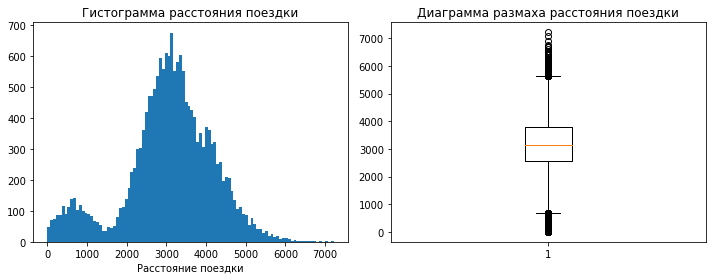

count    18068.000000
mean      3070.659976
std       1116.831209
min          0.855683
25%       2543.226360
50%       3133.609994
75%       3776.222735
max       7211.007745
Name: distance, dtype: float64

In [16]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
axes[0].hist(rides['distance'], bins=100)
axes[0].set_title('Гистограмма расстояния поездки')
axes[0].set_xlabel('Расстояние поездки')
axes[1].boxplot(rides['distance'])
axes[1].set_title('Диаграмма размаха расстояния поездки')
plt.tight_layout()
plt.show()
rides['distance'].describe()

В среднем поездки происходят на расстояние около 3071 метра

Видно два пика: большой около 3000 и маленький около 800

Построим гистограмму и диаграмму размаха для столбца `duration`

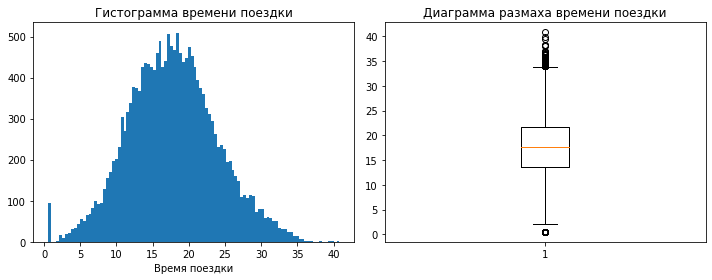

count    18068.000000
mean        17.805011
std          6.091051
min          0.500000
25%         13.597563
50%         17.678395
75%         21.724800
max         40.823963
Name: duration, dtype: float64

In [17]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
axes[0].hist(rides['duration'], bins=100)
axes[0].set_title('Гистограмма времени поездки')
axes[0].set_xlabel('Время поездки')
axes[1].boxplot(rides['duration'])
axes[1].set_title('Диаграмма размаха времени поездки')
plt.tight_layout()
plt.show()
rides['duration'].describe()

В среднем поездка занимает 18 минут

Видно подозрительное множество похожих очень маленьких значений  

Построим диагрмму рассеяния для `distance` и `duration`

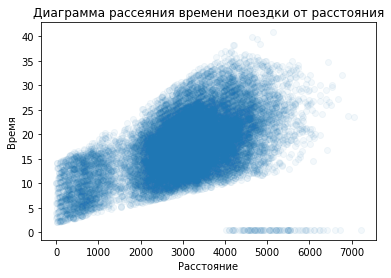

Корреляция:  0.54


In [18]:
plt.scatter(rides['distance'], rides['duration'], alpha=0.05)
plt.xlabel('Расстояние')
plt.ylabel('Время')
plt.title('Диаграмма рассеяния времени поездки от расстояния')
plt.show()
print('Корреляция: ', round(rides['distance'].corr(rides['duration']), 2))

На диаграмме рассеяния видно 2 аномалии:
- Есть множество значений с очень малым временем поездки и очень большим расстоянием
- Поездок с расстоянием около 1500 подозрительно мало

Выведем 10 строк с минимальными значениями `duration`

In [19]:
rides.sort_values('duration').head(10)

,user_id,distance,duration,date,month
12013,1102,4602.122401,0.5,2021-08-01,8
17314,1483,4445.481070,0.5,2021-03-06,3
15029,1318,5894.633314,0.5,2021-03-28,3
7437,766,4539.088310,0.5,2021-12-22,12
12967,1172,4907.140751,0.5,2021-12-19,12
15015,1317,4593.389022,0.5,2021-07-16,7
13012,1176,4935.071045,0.5,2021-05-14,5
7508,772,4718.820996,0.5,2021-05-22,5
16589,1428,5059.187375,0.5,2021-05-06,5
9049,890,4848.485014,0.5,2021-11-20,11


Все 10 минимальных значений `duration` равняются 0.5, посмотрим какую долю они занимают и какое у них среднее расстояние

In [20]:
print(f'Доля: {(rides.query("duration == 0.5")["user_id"].count() / rides["duration"].count()):.2%}')
print(f'Среднее расстояние: {round(rides.query("duration == 0.5")["distance"].mean())} метров')

Доля: 0.53%
Среднее расстояние: 5113 метров


### Таблица `users`

Построим гистограмму частоты встречаемости городов

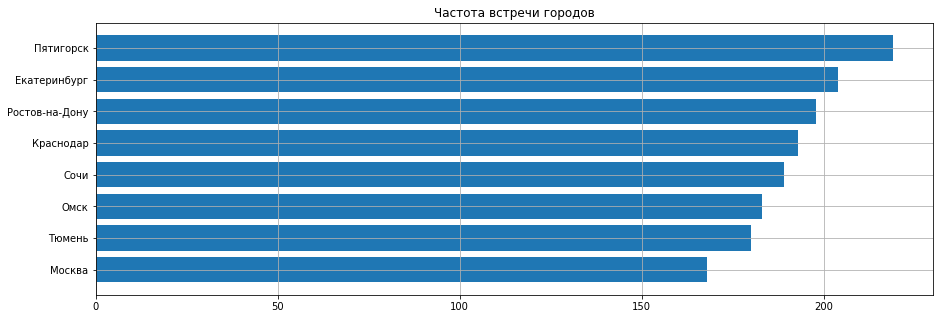

In [21]:
city_counts = users['city'].value_counts().sort_values(ascending=True)
plt.figure(figsize=(15, 5))
plt.barh(city_counts.index, city_counts.values)
plt.title('Частота встречи городов')
plt.grid()
plt.show()

Чаще всего встречаются пользователи из Пятигорска, реже всего из Москвы, но в целом разница не особо большая

Построим гистограмму и диаграмму размаха возраста пользователей

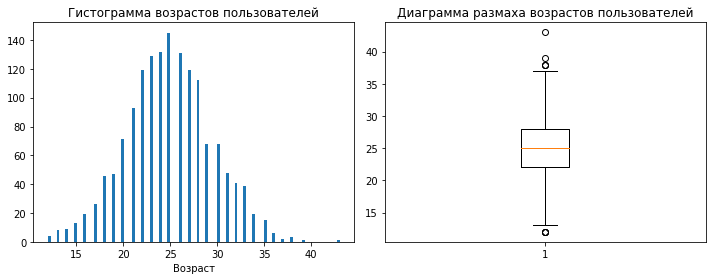

count    1534.000000
mean       24.903520
std         4.572367
min        12.000000
25%        22.000000
50%        25.000000
75%        28.000000
max        43.000000
Name: age, dtype: float64

In [22]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
axes[0].hist(users['age'], bins=100)
axes[0].set_title('Гистограмма возрастов пользователей')
axes[0].set_xlabel('Возраст')
axes[1].boxplot(users['age'])
axes[1].set_title('Диаграмма размаха возрастов пользователей')
plt.tight_layout()
plt.show()
users['age'].describe()

Средний возраст пользователя - 25 лет, минимальный - 12, максимальный - 43

Найдём соотношение пользователей с подпиской и без

In [23]:
print(f'Пользователей с подпиской {(users.loc[users["subscription_type"] == "ultra", "user_id"].count() / users["user_id"].count()):.2%}')
print(f'Пользователей без подписки {(users.loc[users["subscription_type"] == "free", "user_id"].count() / users["user_id"].count()):.2%}')

Пользователей с подпиской 45.57%
Пользователей без подписки 54.43%


Вывод:

- Были построены графики распределений длительности и времени поездки, городов, возраста пользователей
- Найдено соотношение пользователей с подпиской и без (45.57% и 54.43% соответственно)
- Выявлены 2 аномалии в таблице `rides`:
  1. В расстоянии поездок 2 пика около 3000 и около 800 метров
  2. 0.53% датасета составляют поезки со временем 0.5 минут и средним расстоянием 5113 метров

Что делать с аномалиями решим в следующем пункте после раздельного рассмотрения пользователей с подпиской и без

## Шаг 4. Объединение данных

Объединим все три таблицы в одну

In [24]:
data = rides.merge(users, on='user_id', how='left').merge(subs, on='subscription_type', how='left')
data.head(15)

,user_id,distance,duration,date,month,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,4409.919140,25.599769,2021-01-01,1,Кира,22,Тюмень,ultra,6,0,199
1,1,2617.592153,15.816871,2021-01-18,1,Кира,22,Тюмень,ultra,6,0,199
2,1,754.159807,6.232113,2021-04-20,4,Кира,22,Тюмень,ultra,6,0,199
3,1,2694.783254,18.511000,2021-08-11,8,Кира,22,Тюмень,ultra,6,0,199
4,1,4028.687306,26.265803,2021-08-28,8,Кира,22,Тюмень,ultra,6,0,199
5,1,2770.890808,16.650138,2021-10-09,10,Кира,22,Тюмень,ultra,6,0,199
6,1,3039.020292,14.927879,2021-10-19,10,Кира,22,Тюмень,ultra,6,0,199
7,1,2842.118050,23.117468,2021-11-06,11,Кира,22,Тюмень,ultra,6,0,199
8,1,3412.690668,15.238072,2021-11-14,11,Кира,22,Тюмень,ultra,6,0,199
9,1,748.690645,15.041884,2021-11-22,11,Кира,22,Тюмень,ultra,6,0,199


Создадим 2 отдельных датафрейма с пользователями с подпиской и без

In [25]:
sub = data.query('subscription_type == "ultra"')
nosub = data.query('subscription_type == "free"')

Построим графики распределения расстояния и времени поездки для пользователей с подпиской и без

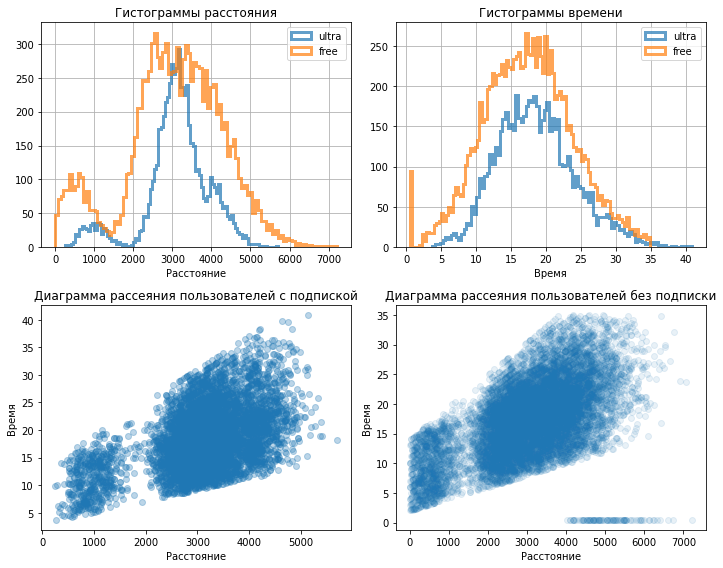

In [26]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
axes[0, 0].hist(sub['distance'], bins=100, histtype='step', linewidth=3, alpha=0.7, label='ultra')
axes[0, 0].hist(nosub['distance'], bins=100, histtype='step', linewidth=3, alpha=0.7, label='free')
axes[0, 0].set_title('Гистограммы расстояния')
axes[0, 0].set_xlabel('Расстояние')
axes[0, 0].legend()
axes[0, 0].grid()

axes[0, 1].hist(sub['duration'], bins=100, histtype='step', linewidth=3, alpha=0.7, label='ultra')
axes[0, 1].hist(nosub['duration'], bins=100, histtype='step', linewidth=3, alpha=0.7, label='free')
axes[0, 1].set_title('Гистограммы времени')
axes[0, 1].set_xlabel('Время')
axes[0, 1].legend()
axes[0, 1].grid()

axes[1, 0].scatter(sub['distance'], sub['duration'], alpha=0.3)
axes[1, 0].set_title('Диаграмма рассеяния пользователей с подпиской')
axes[1, 0].set_xlabel('Расстояние')
axes[1, 0].set_ylabel('Время')

axes[1, 1].scatter(nosub['distance'], nosub['duration'], alpha=0.1)
axes[1, 1].set_title('Диаграмма рассеяния пользователей без подписки')
axes[1, 1].set_xlabel('Расстояние')
axes[1, 1].set_ylabel('Время')

plt.tight_layout()
plt.show()

По построенным графикам можно сказать:
- Два пика расстояний есть у обеих категорий
- Расстояние пользователей без подписок больше распределено
- Аномальные значения с малым временем и большим расстоянием все встречаются у пользователей без подписки

Скорее всего аномальные значения вызваны технической ошибкой (время поездки не записывается), удалим эти значения

In [27]:
nosub = nosub.query('duration != 0.5')
data = data.query('duration != 0.5')

## Шаг 5. Подсчёт выручки

Создадим датафрейм сгруппированный по пользователям и месяцам

In [28]:
#округлим продолжительность до большего значения
data['duration'] = np.ceil(data['duration'])
data2 = data.groupby(['user_id', 'month']).agg({'distance' : 'sum', 'duration' : ['sum', 'count']}).reset_index()
data2.columns = ['user_id', 'month', 'distance_sum', 'duration_sum', 'trip_count']
data2 = data2.merge(users, on='user_id', how='left').merge(subs, on='subscription_type', how='left')
data2

,user_id,month,distance_sum,duration_sum,trip_count,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,1,7027.511294,42.0,2,Кира,22,Тюмень,ultra,6,0,199
1,1,4,754.159807,7.0,1,Кира,22,Тюмень,ultra,6,0,199
2,1,8,6723.470560,46.0,2,Кира,22,Тюмень,ultra,6,0,199
3,1,10,5809.911100,32.0,2,Кира,22,Тюмень,ultra,6,0,199
4,1,11,7003.499363,56.0,3,Кира,22,Тюмень,ultra,6,0,199
...,...,...,...,...,...,...,...,...,...,...,...,...
11295,1534,6,3409.468534,26.0,2,Альберт,25,Краснодар,free,8,50,0
11296,1534,8,7622.453034,48.0,2,Альберт,25,Краснодар,free,8,50,0
11297,1534,9,4928.173852,23.0,1,Альберт,25,Краснодар,free,8,50,0
11298,1534,11,13350.015305,78.0,4,Альберт,25,Краснодар,free,8,50,0


Добавим новый столбец, выручку, которую принёс каждый пользователь за месяц

In [29]:
data2['monthly_spent'] = data2['start_ride_price'] * data2['trip_count'] + data2['minute_price'] * data2['duration_sum'] + data2['subscription_fee']
data2

,user_id,month,distance_sum,duration_sum,trip_count,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee,monthly_spent
0,1,1,7027.511294,42.0,2,Кира,22,Тюмень,ultra,6,0,199,451.0
1,1,4,754.159807,7.0,1,Кира,22,Тюмень,ultra,6,0,199,241.0
2,1,8,6723.470560,46.0,2,Кира,22,Тюмень,ultra,6,0,199,475.0
3,1,10,5809.911100,32.0,2,Кира,22,Тюмень,ultra,6,0,199,391.0
4,1,11,7003.499363,56.0,3,Кира,22,Тюмень,ultra,6,0,199,535.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11295,1534,6,3409.468534,26.0,2,Альберт,25,Краснодар,free,8,50,0,308.0
11296,1534,8,7622.453034,48.0,2,Альберт,25,Краснодар,free,8,50,0,484.0
11297,1534,9,4928.173852,23.0,1,Альберт,25,Краснодар,free,8,50,0,234.0
11298,1534,11,13350.015305,78.0,4,Альберт,25,Краснодар,free,8,50,0,824.0


Был создан датафрейм с данными по пользователям по месяцам, включая общее время поездок, общее расстояние поезок, кол-во поездок, месячную прибыль с того пользователя

## Шаг 6. Проверка гипотез

Продакт-менеджеры сервиса хотят увеличить количество пользователей с подпиской. Для этого они будут проводить различные акции, но сначала нужно выяснить несколько важных моментов.

### Гипотеза 1

Пользователи с подпиской тратят больше времени на поездки.

Нулевая гипотеза - среднее время поездки пользователя с подпиской и без совпадает.

Альтернативная гипотеза - среднее время поездки пользователя с подпиской больше чем без.

$H_0:\mu_{\text{sub}}=\mu_{\text{nosub}}$

$H_1:\mu_{\text{sub}}>\mu_{\text{nosub}}$

Зададим уровень статистической значимости 0.05.

In [30]:
alpha = .05
res = st.ttest_ind(sub['duration'], nosub['duration'], alternative='greater')
print('P-value: ', res.pvalue)
if res.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нет оснований отвергнуть нулевую гипотезу')
print('Среднее время поездки пользователей с подпиской: ', sub['duration'].mean())
print('Среднее время поездки пользователей без подписки: ', nosub['duration'].mean())

P-value:  4.704468074453899e-28
Отвергаем нулевую гипотезу
Среднее время поездки пользователей с подпиской:  18.54198516280583
Среднее время поездки пользователей без подписки:  17.530771268800226


Нулевая гипотеза отвергнута $\implies$ изначальная гипотеза подтверждена, пользователи с подпиской тратят больше времени на поездки

### Гипотеза 2

Расстояние одной поездки в 3130 метров — оптимальное с точки зрения износа самоката. Можно ли сказать, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров?

$H_0:\mu_{sub}=3130$

$H_0:\mu_{sub}>3130$

$\alpha=0.05$

In [31]:
res = st.ttest_1samp(sub['distance'], 3130, alternative='greater')
print('P-value: ', res.pvalue)
if res.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нет оснований отвергнуть нулевую гипотезу')
print('Среднее расстояние поездки пользователей с подпиской: ', sub['distance'].mean())

P-value:  0.9195368847849785
Нет оснований отвергнуть нулевую гипотезу
Среднее расстояние поездки пользователей с подпиской:  3115.4453880370247


Нулевая гипотеза не отвергнута $\implies$ изначальная гипотеза подтверждена, среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров

### Гипотеза 3

Будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки?

$H_0 : \mu_{sub} = \mu_{nosub}$

$H_1 : \mu_{sub} > \mu_{nosub}$

$\alpha=0.05$

In [32]:
alpha = .05
res = st.ttest_ind(data2.query('subscription_type == "ultra"')['monthly_spent'], 
                   data2.query('subscription_type == "free"')['monthly_spent'], 
                   alternative='greater')
print('P-value: ', res.pvalue)
if res.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нет оснований отвергнуть нулевую гипотезу')
print('Среднее выручка за месяц с пользователей с подпиской: ', data2.query('subscription_type == "ultra"')['monthly_spent'].mean())
print('Среднее выручка за месяц с пользователей без подписки: ', data2.query('subscription_type == "free"')['monthly_spent'].mean())

P-value:  2.0314113674863288e-30
Отвергаем нулевую гипотезу
Среднее выручка за месяц с пользователей с подпиской:  362.7921906022502
Среднее выручка за месяц с пользователей без подписки:  329.3326437121324


Нулевая гипотеза отвергнута $\implies$ изначальная гипотеза подтверждена, помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки

### Гипотеза 4

Представим такую ситуацию: техническая команда сервиса обновила сервера, с которыми взаимодействует мобильное приложение. Она надеется, что из-за этого количество обращений в техподдержку значимо снизилось. Некоторый файл содержит для каждого пользователя данные о количестве обращений до обновления и после него. 

Для проверки такой гипотезы понадобился бы метод `scipy.stats.ttest_rel()` т. к. вышеописанные выборки зависимы друг от друга.

Вывод:

В данном пункте мы выяснили несколько важных моментов для увеличения кол-ва пользователей с подпиской путём запуска рекламы:
1. Пользователи с подпиской тратят больше времени на поезку, следовательно стоит рекламировать выгодность подписки для долгих поездок.
2. Среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров, если узнать расстояние от работы до дома пользователей, можно было бы активно рекламировать подписку тем, у кого работа находится на расстоянии менее 3130 метров от дома.
3. Помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки, что доказывает в целом важность рекламы подписки.
4. После реализации рекламной компании, при проверке её успешности следует использовать метод `scipy.stats.ttest_rel()`.

## Вывод


По полученным данным была проведена следующая работа:

Предобработка данных:

- Столбец `date` приведён к типу Datetime
- Создан столбец `month` с номером месяца на основе `date`
- Убраны повторяющиеся строки в таблице `users`
- Сокращённые формы имён заменены на полные в столбце `name` таблицы `users`

Исследовательский анализ данных:

- Были построены графики распределений длительности и времени поездки, городов, возраста пользователей
- Найдено соотношение пользователей с подпиской и без (45.57% и 54.43% соответственно)
- Выявлены 2 аномалии в таблице `rides`:
  1. В расстоянии поездок 2 пика около 3000 и около 800 метров
  2. 0.53% датасета составляют поезки со временем 0.5 минут и средним расстоянием 5113 метров

Объединение данных:

- Данные всех трёх изначальных таблиц были объединены
- Была визуализирована информация о расстоянии и времени поездок для пользователей с подпиской и без
- Аномальные значения, найденые в предыдущем пункте втречаются только у пользователей без подписки, они были удалены

Подсчёт выручки:

- Был создан датафрейм с данными по пользователям по месяцам, включая общее время поездок, общее расстояние поезок, кол-во поездок, месячную прибыль с того пользователя

Проверка гипотез:

В данном пункте мы выяснили несколько важных моментов для увеличения кол-ва пользователей с подпиской путём запуска рекламы:
1. Пользователи с подпиской тратят больше времени на поезку, следовательно стоит рекламировать выгодность подписки для долгих поездок.
2. Среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров, если узнать расстояние от работы до дома пользователей, можно было бы активно рекламировать подписку тем, у кого работа находится на расстоянии менее 3130 метров от дома.
3. Помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки, что доказывает в целом важность рекламы подписки.
4. После реализации рекламной компании, при проверке её успешности следует использовать метод `scipy.stats.ttest_rel()`.

Рекомендации заказчику:

- Разобраться в причине некорректной записи времени поездки у пользователей без подписки.
- Следуя выводам полученным в пункте `Проверка гипотез` провести рекламную компанию по увеличению пользователей с подпиской и проверить её успешность методом `scipy.stats.ttest_rel()`.